In [1]:
import pandas as pd
import numpy as np
from pandas import DataFrame

In [3]:
#import raw_department table
path3='/content/raw-department.txt'
raw_department=pd.read_csv(path3,sep='-')
raw_department

,department_id,department_name
0,1,General
1,2,Sales Support
2,3,IT


In [4]:
#import raw-department-budget table
with open('raw-department-budget.txt','r') as file:
    data = file.readlines()
data

['{"sub_dep_id":1, "sub_dep_name":"managers", "department_id":1, "budget":3000}\n',
 '{"sub_dep_id":2, "sub_dep_name":"managers2", "department_id":1, "budget":1500}\n',
 '{"sub_dep_id":1, "sub_dep_name":"sales support john", "department_id":2, "budget":2000}\n',
 '{"sub_dep_id":2, "sub_dep_name":"sales support joe", "department_id":2, "budget":1000}\n',
 '{"sub_dep_id":3, "sub_dep_name":"sales support johnson", "department_id":2, "budget":2500}\n',
 '{"sub_dep_id":4, "sub_dep_name":"sales support eduards", "department_id":2, "budget":2500}']

In [ ]:
json_str = ''.join(data)

raw_department_budget = pd.read_json(json_str, lines=True)
raw_department_budget

<ipython-input-4-ce3348d2435b>:3: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  raw_department_budget = pd.read_json(json_str, lines=True)


,sub_dep_id,sub_dep_name,department_id,budget
0,1,managers,1,3000
1,2,managers2,1,1500
2,1,sales support john,2,2000
3,2,sales support joe,2,1000
4,3,sales support johnson,2,2500
5,4,sales support eduards,2,2500


In [ ]:
#import raw_department_budget2 table
raw_department_budget2 = pd.read_json('raw-department-budget2.txt')
raw_department_budget2

,sub_dep_id,sub_dep_name,department_id,budget
0,1,IT purchases,3,2000
1,2,IT maintenance,3,1500
2,3,IT other,3,1000


In [ ]:
#union between raw_department_budget and raw_department_budget2
union_department_budget=pd.concat([raw_department_budget,raw_department_budget2],axis=0).reset_index(drop='True')
union_department_budget

,sub_dep_id,sub_dep_name,department_id,budget
0,1,managers,1,3000
1,2,managers2,1,1500
2,1,sales support john,2,2000
3,2,sales support joe,2,1000
4,3,sales support johnson,2,2500
5,4,sales support eduards,2,2500
6,1,IT purchases,3,2000
7,2,IT maintenance,3,1500
8,3,IT other,3,1000


In [ ]:
#merge between raw_department and union_department_budget ,
#and creat department_budget table order by the assignment
merge_department=pd.merge(raw_department,union_department_budget,on='department_id',how='left')
department_budget=merge_department.groupby(['department_id','department_name'])['budget'].sum().reset_index()
department_budget

,department_id,department_name,budget
0,1,General,4500
1,2,Sales Support,8000
2,3,IT,4500


In [5]:
#Connecting to debeaver
import sqlalchemy
from sqlalchemy import create_engine

In [6]:
user='postgres.zvndhlwsooeamasytbwi'
password='Esproject123++'
host='aws-0-eu-central-1.pooler.supabase.com'
dbname='chinook'
conn_string = 'postgresql+psycopg2://{user}:{password}@{host}/{dbname}'.format(user = user, password = password, host = host, dbname = dbname)
engine = create_engine(conn_string)

In [ ]:
with engine.connect() as connection:
    department_budget.to_sql('department_budget', con=connection, index=False,schema='stg',if_exists='replace')

In [ ]:
#part 2 - API (we do the sql part before)

In [13]:
#import all the table in dwh to python
dim_employee = pd.read_sql("SELECT * FROM dwh.dim_employee", engine)
dim_customer = pd.read_sql("SELECT * FROM dwh.dim_customer", engine)
dim_playlist = pd.read_sql("SELECT * FROM dwh.dim_playlist", engine)
dim_track = pd.read_sql("SELECT * FROM dwh.dim_track", engine)
fact_invoice = pd.read_sql("SELECT * FROM dwh.fact_invoice", engine)
fact_invoiceline = pd.read_sql("SELECT * FROM dwh.fact_invoiceline", engine)
dim_currency = pd.read_sql("SELECT * FROM dwh.dim_currency", engine)

In [7]:
!pip install freecurrencyapi

  Preparing metadata (setup.py) ... done
  Created wheel for freecurrencyapi: filename=freecurrencyapi-0.1.0-py3-none-any.whl size=2610 sha256=18cde83bc49ce7bd7c0461432a6e35d652f9daeb5f6b66451da12b89a618fe0e
  Stored in directory: /root/.cache/pip/wheels/88/da/71/65b87f58eadc422f8dbc15c69c70e0990a8283c5bbd7cc9e63
Successfully built freecurrencyapi


In [8]:
import freecurrencyapi
client = freecurrencyapi.Client('fca_live_U91rgqhHMcoNo8NDAh5HgYhAOsMRBAg1ukcLpcnp')

In [9]:
print(client.status())

{'account_id': 368469392780038144, 'quotas': {'month': {'total': 5000, 'used': 879, 'remaining': 4121}, 'grace': {'total': 0, 'used': 0, 'remaining': 0}}}


In [10]:
result = client.currencies(currencies=['ILS'])
print(result)

{'data': {'ILS': {'symbol': '₪', 'name': 'Israeli New Sheqel', 'symbol_native': '₪', 'decimal_digits': 2, 'rounding': 0, 'code': 'ILS', 'name_plural': 'Israeli new sheqels', 'type': 'fiat'}}}


In [ ]:
#test 1
x='2024-10-10'
result = client.historical(x)
print(result)

{'data': {'2024-10-10': {'AUD': 1.4836501529, 'BGN': 1.7827103477, 'BRL': 5.5813810072, 'CAD': 1.374440271, 'CHF': 0.8564401642, 'CNY': 7.0775111343, 'CZK': 23.155513299, 'DKK': 6.822741127, 'EUR': 0.9144301292, 'GBP': 0.765710079, 'HKD': 7.7686311061, 'HRK': 6.4821511549, 'HUF': 366.8484695334, 'IDR': 15640.024848256, 'ILS': 3.7597406049, 'INR': 83.9253719183, 'ISK': 135.9089604346, 'JPY': 148.6887315154, 'KRW': 1347.7647350818, 'MXN': 19.4408033941, 'MYR': 4.2893006353, 'NOK': 10.7352414079, 'NZD': 1.6406802294, 'PHP': 57.4787395524, 'PLN': 3.9325506188, 'RON': 4.5501508275, 'RUB': 97.0267404834, 'SEK': 10.386841182, 'SGD': 1.3059202321, 'THB': 33.4353038218, 'TRY': 34.2454357144, 'USD': 1, 'ZAR': 17.5252929075}}}


In [ ]:
#test 2
x='2024-10-10'
result = client.historical(date=x,currencies=['ILS'])
print(result['data'][x]['ILS'])

3.7597406049


In [ ]:
# import library to use the timedelta function
from datetime import datetime, timedelta

In [ ]:
# create 2 lists (dates, shekels)
start_date = fact_invoice['invoicedate'].min() # first invoice date
end_date = fact_invoice['invoicedate'].max() # last invoice date

start_date_str = pd.to_datetime(start_date).strftime('%Y-%m-%d') #convert to string
result = client.historical(start_date_str,currencies=['ILS']) # in order to convert dollar to shekel according the first date
min_curr=result['data'][start_date_str]['ILS']
#print(min_curr)

end_date_str = pd.to_datetime(end_date).strftime('%Y-%m-%d') #convert to string
result = client.historical(end_date_str,currencies=['ILS'])  # in order to convert dollar to shekel according the last date
max_curr=result['data'][end_date_str]['ILS']
#print(max_curr)
avg=(min_curr+max_curr)/2  # Calculation of the average to dates with no convert to shekel
#print(avg)


current_date = start_date # variable
l_date=[] # definition list of dates
l_curre=[] # definition list of shekel currencies
for x in range((end_date-start_date).days +1): #running loop for the dates diff is the amount times (plus 1 to include the last date)
  date_str = pd.to_datetime(current_date).strftime('%Y-%m-%d') #convert to string
  result = client.historical(date_str,currencies=['ILS']) # # in order to convert dollar to shekel according the date
  if 'data' in result: #if the word 'data' that support to be in the result , will exist then append to the lists
    l_date.append(date_str)
    l_curre.append(result['data'][date_str]['ILS'])
    #print(f"{date_str}: {result['data'][date_str]['ILS']}")
  else: #if not exist in the result, then put the avg between the min_curr and max_curr
    l_date.append(date_str)
    l_curre.append(avg)
    #print(f"{date_str}: {avg}")
  current_date += timedelta(days=1) # after finish in any loop add one day to the variable date and running the loop all over again with the new variable
#print(l_date,l_curre)

In [ ]:
# convert the 2 list to dictionary and create table
dim_currency_table = {'date':l_date,'currency' : l_curre}
dim_currency = DataFrame(dim_currency_table)
dim_currency

,date,currency
0,2018-01-01,3.466690
1,2018-01-02,3.447580
2,2018-01-03,3.447070
3,2018-01-04,3.443100
4,2018-01-05,3.428190
...,...,...
1812,2022-12-18,3.481222
1813,2022-12-19,3.481222
1814,2022-12-20,3.481222
1815,2022-12-21,3.481222


In [ ]:
#add the table to stg schema
with engine.connect() as connection:
    dim_currency.to_sql('dim_currency', con=connection, index=False,schema='stg',if_exists='replace')

In [ ]:
#part 3 -analysis

In [ ]:
#q.1
#5 top:
#של האומנים עם הכי הרבה אלבומים
#(tracks) של האומנים עם הכי הרבה שירים
#של הז'אנרים עם הכי הרבה שירים

In [17]:
relevent_table=dim_track[['artist_name','albumid']]
top_5_album_artist=relevent_table.groupby('artist_name')['albumid'].nunique().reset_index().sort_values(by='albumid',ascending=False).head() #top 5 artist most albums
artist_album_table=dim_track[['artist_name','trackid']]
top_5_track_artist=artist_album_table.groupby('artist_name')['trackid'].count().reset_index().sort_values(by='trackid',ascending=False).head()#top 5 artist most tracks
gener_track_table=dim_track[['gener_name','trackid']]
top_5_genre_track=gener_track_table.groupby('gener_name')['trackid'].count().reset_index().sort_values(by='trackid',ascending=False).head()#top 5 gener most tracks
print(top_5_album_artist,top_5_track_artist,top_5_genre_track)

      artist_name  albumid
91    Iron Maiden       21
107  Led Zeppelin       14
54    Deep Purple       11
125     Metallica       10
194            U2       10       artist_name  trackid
91    Iron Maiden      213
194            U2      135
107  Led Zeppelin      114
125     Metallica      112
113          Lost       92             gener_name  trackid
18                Rock     1297
12               Latin      579
13               Metal      374
1   Alternative & Punk      332
11                Jazz      130


In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

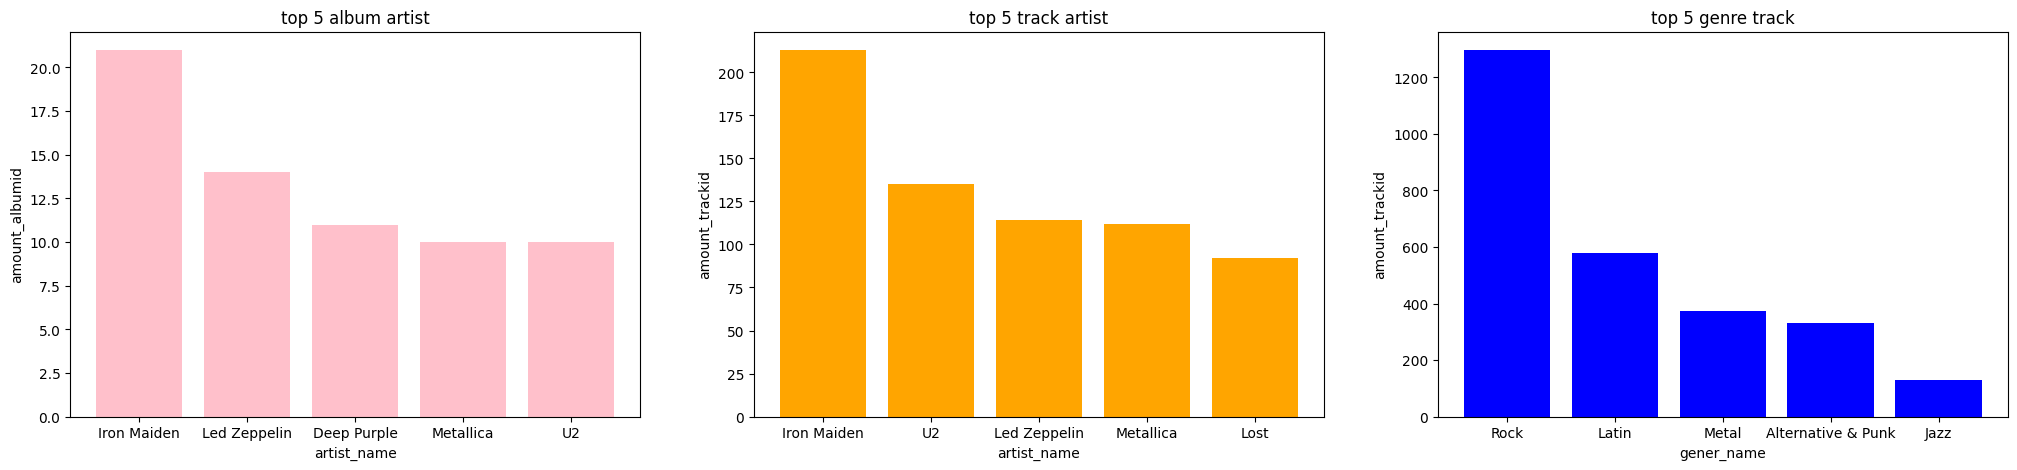

In [22]:
# 1 figure,3 subplots
fig, ax= plt.subplots(1,3,figsize=(25,5))
ax[0].bar(top_5_album_artist['artist_name'],top_5_album_artist['albumid'],color='pink')
ax[0].set_xlabel('artist_name')
ax[0].set_ylabel('amount_albumid')
ax[0].set_title('top 5 album artist')
ax[1].bar(top_5_track_artist['artist_name'],top_5_track_artist['trackid'],color='orange')
ax[1].set_xlabel('artist_name')
ax[1].set_ylabel('amount_trackid')
ax[1].set_title('top 5 track artist')
ax[2].bar(top_5_genre_track['gener_name'],top_5_genre_track['trackid'],color='blue')
ax[2].set_xlabel('gener_name')
ax[2].set_ylabel('amount_trackid')
ax[2].set_title('top 5 genre track')
plt.show()

In [ ]:
#q2
#(מיהם 5 הלקוחות שרכשו בסכומים הגבוהים ביותר? מהו הסכום (בדולרים וגם בשקלים

In [25]:
dim_currency['date']=pd.to_datetime(dim_currency['date']) #convert date column to date type
merge_table=pd.merge(dim_customer, fact_invoice, on='customerid' ,how='inner') # merge tables
merge_table=pd.merge(merge_table, dim_currency, left_on='invoicedate', right_on='date', how='inner') # merge tables
merge_table['full_name']=merge_table['firstname']+' '+merge_table['lastname'] #create column full name
merge_table['shekels_total']=merge_table['total']*merge_table['currency'] #create new column shekels total
top_5_customer_sales = merge_table.groupby('full_name').agg({'total':sum, 'shekels_total':sum}).reset_index().sort_values(by = 'total',ascending=False).head() #top 5 customer most sales(shekel+dollar)
top_5_customer_sales

<ipython-input-25-6bbb868b7556>:6: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  top_5_customer_sales = merge_table.groupby('full_name').agg({'total':sum, 'shekels_total':sum}).reset_index().sort_values(by = 'total',ascending=False).head() #top 5 customer most sales(shekel+dollar)
<ipython-input-25-6bbb868b7556>:6: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  top_5_customer_sales = merge_table.groupby('full_name').agg({'total':sum, 'shekels_total':sum}).reset_index().sort_values(by = 'total',ascending=False).head() #top 5 customer most sales(shekel+dollar)


,full_name,total,shekels_total
507,Puja Srivastava,71.31,246.092192
153,Denise Kelly,65.36,227.840219
333,Josephine Gomez,55.44,192.998948
261,Helena Holý,49.62,172.738236
525,Richard Cunningham,47.62,165.775792


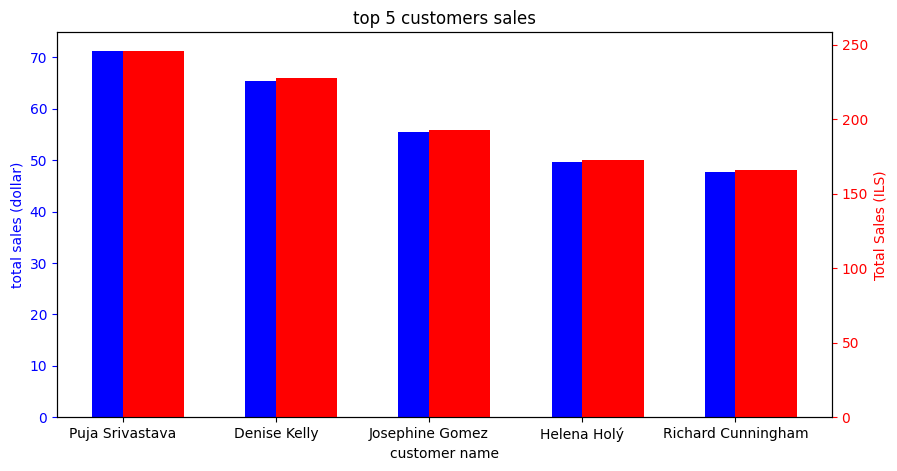

In [ ]:
fig,ax=plt.subplots(figsize=(10,5))
ax.bar(top_5_customer_sales['full_name'],top_5_customer_sales['total'],color='blue',width=0.4,align='center')
ax.tick_params('y', colors = 'blue')

ax2 = ax.twinx()
ax2.bar(top_5_customer_sales['full_name'],top_5_customer_sales['shekels_total'], color= 'red', width=0.4,align='edge')
ax2.tick_params('y', colors = 'red')

ax.set_xlabel('customer name')
ax.set_ylabel('total sales (dollar)',color='blue')
ax.set_title('top 5 customers sales')

ax2.set_ylabel('Total Sales (ILS)', color='red')
plt.show()




In [ ]:
#3
#הציגו גרף של סכום מכירות עבור כל חודש בכל שנה

In [ ]:
new_inviove_table=fact_invoice.copy()
new_inviove_table['year_month']=pd.to_datetime(fact_invoice['invoicedate']).dt.strftime("%Y-%m") #new column year_month in string type
sales_year_month=new_inviove_table.groupby(['year_month'])['total'].sum().reset_index() # sales per year_month
sales_year_month.head(4)

,year_month,total
0,2018-01,201.01
1,2018-02,237.68
2,2018-03,233.66
3,2018-04,262.45


<ipython-input-164-9beb6be28ec4>:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sales_year_month['year_month'],rotation=90)


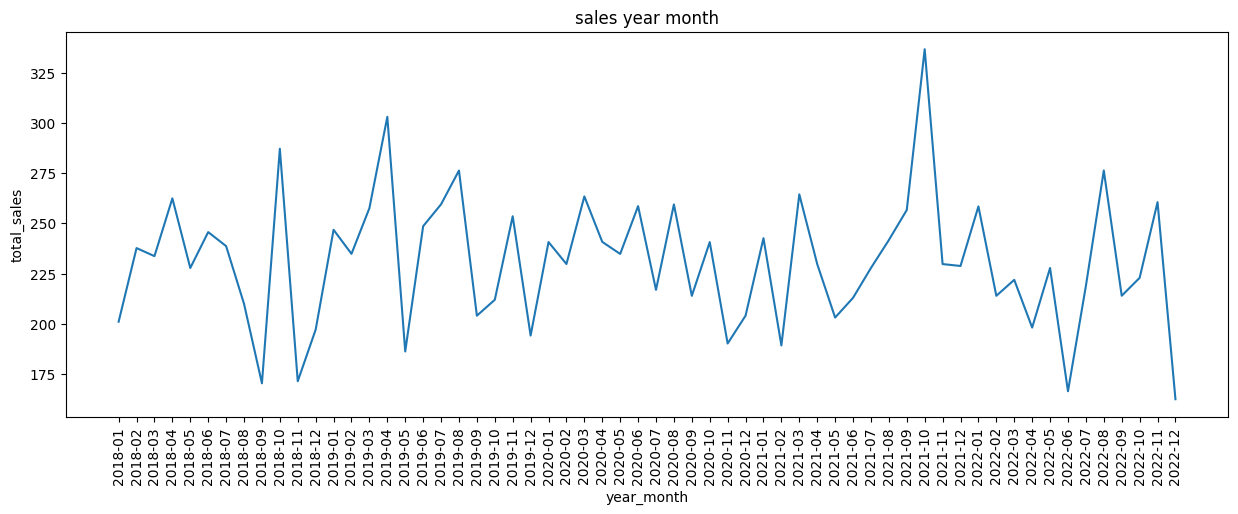

In [ ]:
fig,ax=plt.subplots(figsize=(15,5))
ax.plot(sales_year_month['year_month'],sales_year_month['total'])
ax.set_xticklabels(sales_year_month['year_month'],rotation=90)
ax.set_xlabel('year_month')
ax.set_ylabel('total_sales')
ax.set_title('sales year month')
plt.show()

In [ ]:
#4
#האם קיימת קורלציה בין אורך השיר לבין סכום המכירות שלו?

In [19]:
merge_tables=pd.merge(dim_track,fact_invoiceline,on='trackid',how='left') #merge tables
relevent_tables=merge_tables[['seconds','line_total']]
len_track_sales=relevent_tables.groupby('seconds')['line_total'].sum().reset_index() #sales per length track
len_track_sales.head(3)

,seconds,line_total
0,1,5.94
1,4,3.96
2,6,9.90


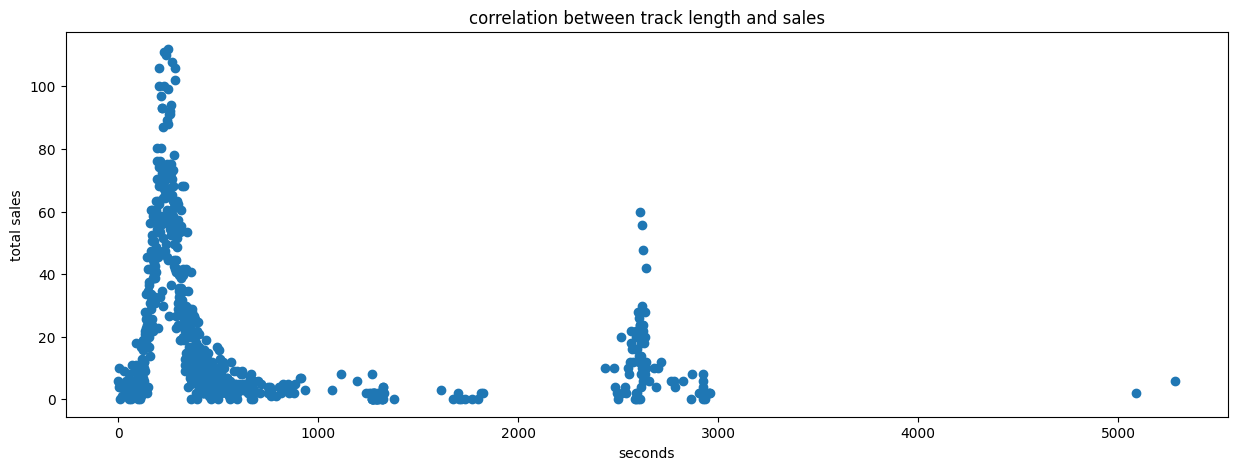

In [26]:
fig,ax=plt.subplots(figsize=(15,5))
ax.scatter(len_track_sales['seconds'],len_track_sales['line_total'])
ax.set_xlabel('seconds')
ax.set_ylabel('total sales')
ax.set_title('correlation between track length and sales')
plt.show()

In [ ]:
# כתבו קטע קוד שיספק המלצות לשירים עבור לקוחות. ההמלצה תכלול 6 שירים לרכישה לפי התנאים הבאים
#-( השירים הפופולריים ביותר המשתייכים ל2- הז'אנרים המועדפים על הלקוח (3 מכל ז'אנר
#- טרם נרכשו על ידי הלקוח

In [28]:
def my_func(first,last):
  merge_tab= pd.merge(dim_customer,fact_invoice,on='customerid',how='left',suffixes=('_customer','_invoice')) #merge tables
  merge_tab= pd.merge(merge_tab,fact_invoiceline,on='invoiceid',how='left')
  merge_tab= pd.merge(merge_tab ,dim_track ,on='trackid',how='left',suffixes=('_invoiceline','_track')) #suffixes because the last_update columns
  relevent_column_table=merge_tab[['customerid','firstname','lastname','gener_name','trackid','track_name','quantity']] #general_table
  customer_table=relevent_column_table[(relevent_column_table['firstname']==first) & (relevent_column_table['lastname']==last)] #table_per_customer
  top2_gener_customer=customer_table.groupby('gener_name')['quantity'].sum().reset_index().sort_values(by='quantity',ascending=False).head(2) #top2 gener for customer
  top2_gener_all_customer=relevent_column_table[relevent_column_table['gener_name'].isin(top2_gener_customer['gener_name'])] #sales general for 2 top gener
  all_track_customer_not_buy=top2_gener_all_customer[~top2_gener_all_customer['trackid'].isin(customer_table['trackid'])] # tracks customer didnt purchase from the 2 gener
  track_gener=all_track_customer_not_buy.groupby(['gener_name','trackid','track_name'])['quantity'].sum().reset_index() #total quantity per track and gener
  gener1=track_gener[track_gener['gener_name']==top2_gener_customer.iloc[0,0]] #table_per_gener1
  gener2=track_gener[track_gener['gener_name']==top2_gener_customer.iloc[1,0]] #table_per_gener2

  top3_track_per_gener1 = gener1.nlargest(3,'quantity') #top 3 track order gener one
  top3_track_per_gener2= gener2.nlargest(3,'quantity') #top 3 track order gener two
  recommended_6_tracks = pd.concat( [top3_track_per_gener1[['gener_name','trackid','track_name']], top3_track_per_gener2[['gener_name','trackid','track_name']]]) #top3+top3
  return recommended_6_tracks
my_func('Tim','Goyer')

,gener_name,trackid,track_name
1565,Rock,2672,Paint It Black
996,Rock,1401,Judgement Of Heaven
1263,Rock,2153,Elderly Woman Behind The Counter In A Small Town
93,Latin,380,Samba da Bençaco
36,Latin,241,Geni E O Zepelim
174,Latin,594,Agora Que O Dia Acordou


In [15]:
#q.6 אנליזה נוספת מעצמנו
fact_invoice['quarter'] = fact_invoice['invoicedate'].dt.quarter #create column quarter
sales_orders_per_quarter= fact_invoice.groupby('quarter').agg({'invoiceid':'count' , 'total' : sum}).reset_index().sort_values(by = 'total', ascending=False) # total sales and orders per quarter
sales_orders_per_quarter=sales_orders_per_quarter.sort_values(by ='quarter') #sorting by quarter
sales_orders_per_quarter

<ipython-input-15-de828e4289ac>:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sales_orders_per_quarter= fact_invoice.groupby('quarter').agg({'invoiceid':'count' , 'total' : sum}).reset_index().sort_values(by = 'total', ascending=False)


,quarter,invoiceid,total
0,1,964,3535.77
1,2,954,3445.63
2,3,960,3484.01
3,4,933,3390.96


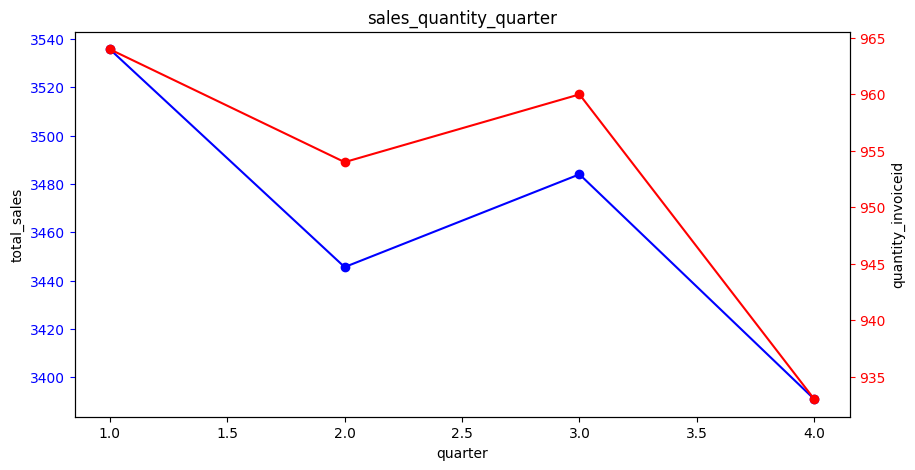

In [16]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(sales_orders_per_quarter['quarter'],sales_orders_per_quarter['total'], color= 'blue', marker='o')
ax.tick_params('y', colors = 'blue')
ax2 = ax.twinx()
ax2.plot(sales_orders_per_quarter['quarter'],sales_orders_per_quarter['invoiceid'], color= 'red', marker='o')
ax2.tick_params('y', colors = 'red')
ax.set_xlabel('quarter')
ax.set_ylabel('total_sales')
ax2.set_ylabel('quantity_invoiceid')
ax.set_title('sales_quantity_quarter')
plt.show()